### Needs to be executed in decoupler_liana environment

In [1]:
# Import Libraries
import scanpy as sc
import liana as li

In [2]:
# Set Paths
project_path = "/home/usuario/PROJECTS/260724_victor_scRNA/"
results_path = project_path + "results/"
results_GEMX_CC_path = results_path + "GEMX/CellCommunication/7500/"

In [3]:
# Load Annotated Data in .h5ad Format
adata = sc.read_h5ad(results_GEMX_CC_path + "fully_annotated_data.h5ad")

In [4]:
# Execute LIANA
li.mt.rank_aggregate(adata, groupby="celltype", resource_name="consensus",
                       expr_prop=0.1, layer="data_RNA", use_raw=False, verbose=True)
liana_res = adata.uns["liana_res"]

Using resource `consensus`.
Using the `data_RNA` layer!
Converting to sparse csr matrix!
1 features of mat are empty, they will be removed.
/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.05 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 152093 samples and 1770 features


/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [01:16<00:00, 13.04it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [27]:
liana_res.to_csv(results_GEMX_CC_path+'liana.tsv', sep="\t", index=True)

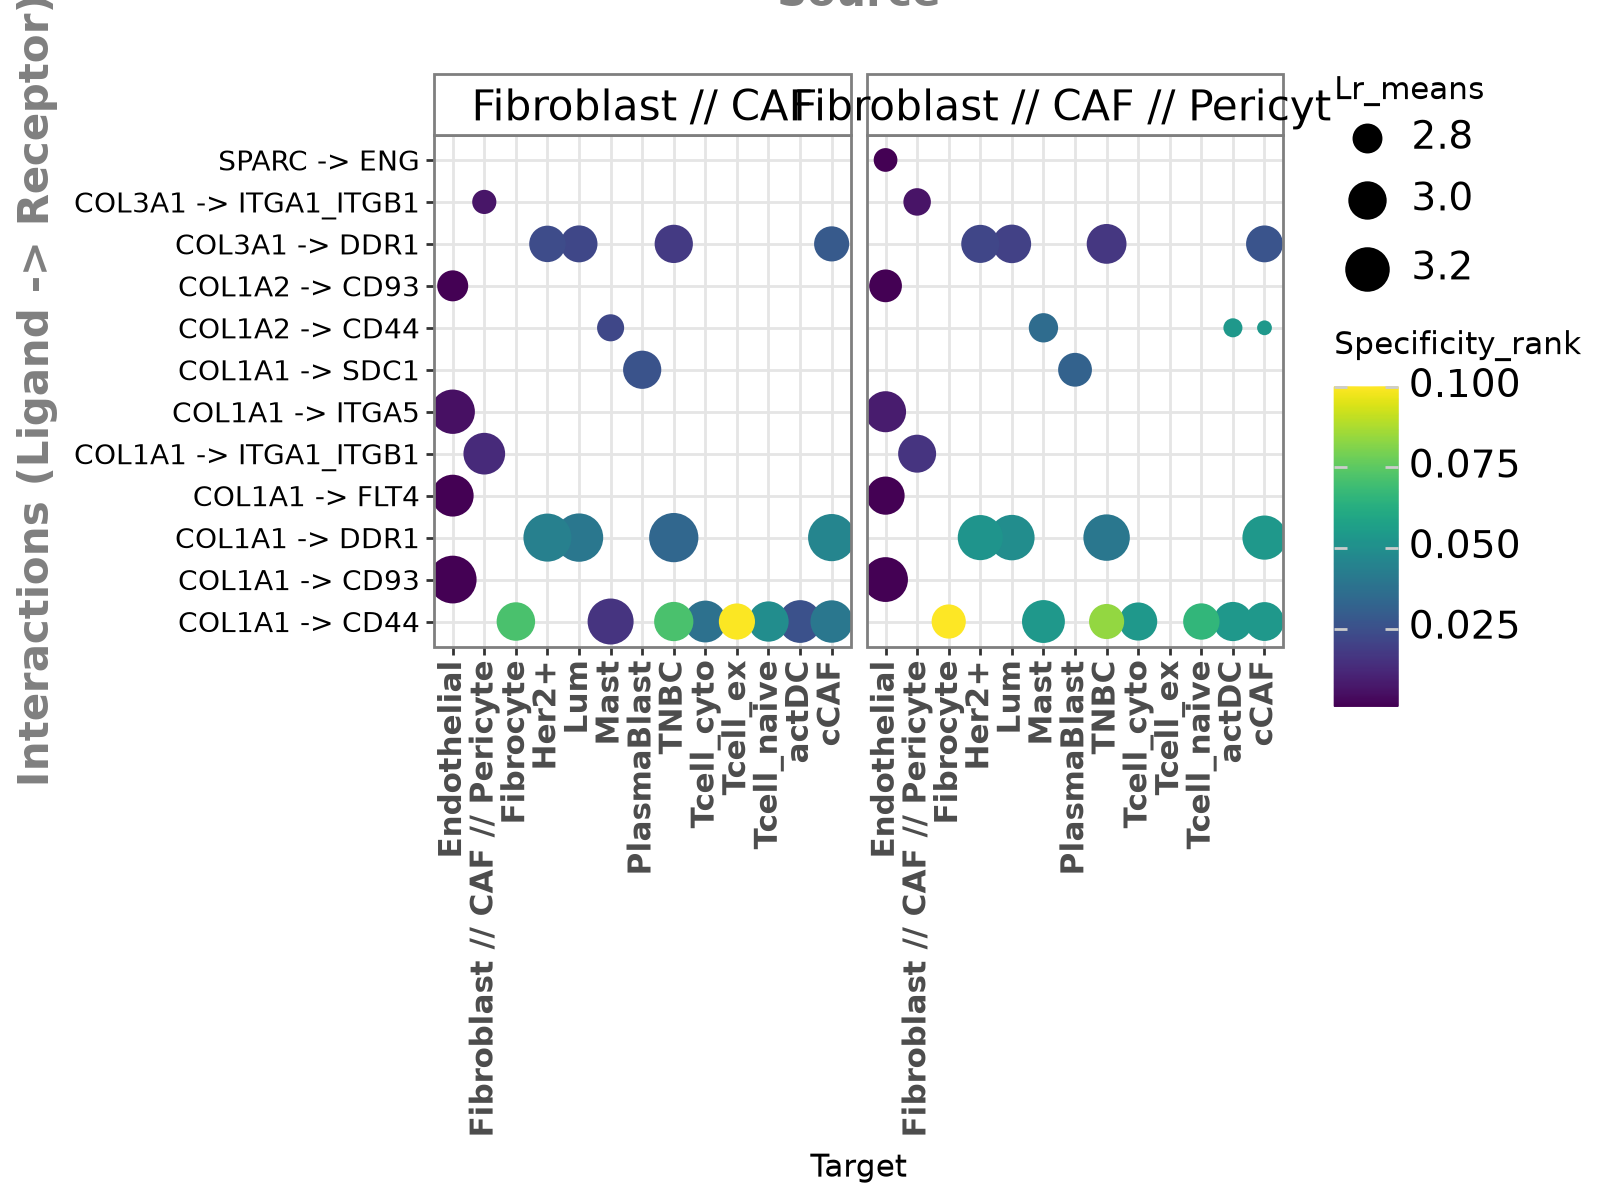

In [28]:
li.pl.dotplot(liana_res=liana_res[:50], size="lr_means", colour="specificity_rank")

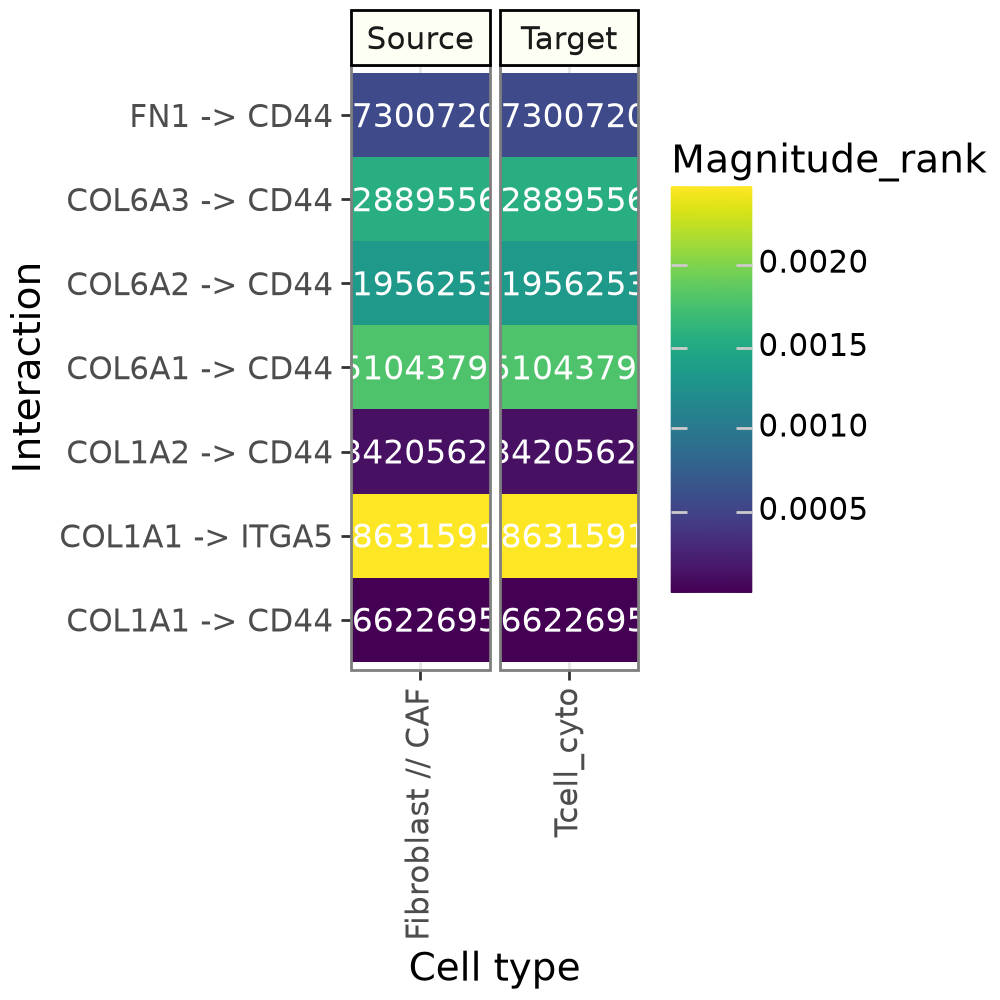

In [36]:
li.pl.tileplot(
    liana_res=liana_res[:500],
    source_labels=["Fibroblast // CAF", "TNBC"],
    target_labels=["Tcell_cyto", "MAST"],
    fill="magnitude_rank",
    label="lr_means"
)

/home/usuario/miniconda3/envs/decoupler_liana/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Axes: >

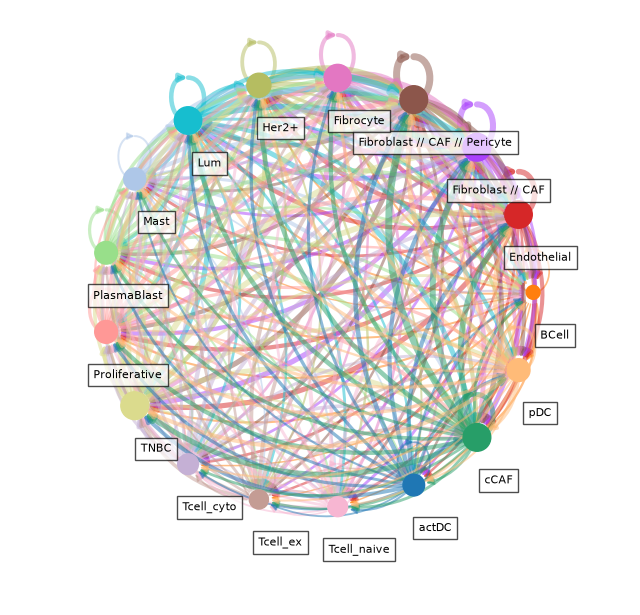

In [7]:
li.pl.circle_plot(
    adata,
    groupby="celltype",
    score_key="magnitude_rank",
    inverse_score=True,     # magnitude_rank es tipo p-value (menor=mejor), invierte para que "más ancho=más fuerte"
    top_n=50,
    orderby="magnitude_rank",
    orderby_ascending=True,
    pivot_mode="counts",     # nº de interacciones significativas por par (como tu heatmap)
    figure_size=(8, 8),
)